# Section 1 &middot; Your First ML Loop

*The Honest Edge.*

We will run the entire supervised machine-learning loop, end to end, on the
simplest question a trader can ask: **will SPY close up tomorrow?**

The answer is going to be deflating, and the deflation is the whole point. By the
end you will have trained a real model, scored it honestly, and watched it tie a
brain-dead baseline. Understanding *why* is what makes everything later worth
doing.

## The loop, in one analogy: studying for an exam

Every supervised model does the same five things. Think of cramming from past
exam papers:

| ML term | Exam analogy | In scikit-learn |
|---|---|---|
| **features (X)** | the clues on each question | a table of numbers describing SPY *today* |
| **label (y)** | the answer key | did SPY go up *tomorrow*? (1 or 0) |
| **train** | study past papers with answers | `model.fit(X_train, y_train)` |
| **test** | sit a fresh, unseen exam | `model.predict(X_test)` |
| **accuracy** | your exam grade | `accuracy_score(y_test, predictions)` |

So the three action verbs map cleanly: **train = fit**, **test = predict**,
**score = accuracy**. The whole flow, start to finish:

```
features (X)  ->  label (y)  ->  fit (train)  ->  predict (test)  ->  score (accuracy)
```

One rule carries over from Section 0: **a score is meaningless until you know the
passing mark.** Hold that thought; it is the trap this whole section springs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from honest_edge import data, indicators as ind

spy = data.load_spy_daily()
print("shape:", spy.shape, " range:", spy.index.min().date(), "->", spy.index.max().date())

shape: (5000, 6)  range: 2006-05-05 -> 2026-03-20


## A 60-second pandas primer (and the toolkit)

If you come from plain Python, the thing that makes **pandas** click is this: you
stop writing `for` loops over data. You describe an operation on a whole **column**
at once, and pandas runs the loop for you, in fast C, lined up by date.

- A **Series** is one labeled column (here, indexed by date). A **DataFrame** is a
  table of Series sharing that same index.
- The **index** is the row labels (our dates). When you combine two columns, pandas
  lines them up by index automatically, so you never juggle "which row is which."
- Operations are **vectorized**: `close.pct_change()` computes a return for every
  row in a single line, with no loop and no off-by-one bookkeeping.

The handful of moves used in this section, in plain English:

| pandas | what it does |
|---|---|
| `close.pct_change(n)` | percent change vs `n` rows ago (a return) |
| `close.rolling(n).mean()` | average of the last `n` rows (a moving average) |
| `s.shift(k)` | slide values down (`k > 0`, look back) or up (`k < 0`, look forward) |
| `df.iloc[a:b]` | select rows by *position* (like list slicing) |
| `s.dropna()` | drop rows that are `NaN` (empty / undefined) |

And the ML toolbox, **scikit-learn** (`sklearn`), where every model follows the same
`.fit()` then `.predict()` pattern:

- `LogisticRegression` &middot; a simple linear classifier that outputs a probability.
- `DecisionTreeClassifier` &middot; a flexible model that splits on feature thresholds
  (we use it later to *demonstrate overfitting*).
- `accuracy_score(truth, prediction)` &middot; the share of calls it got right.
- `train_test_split` &middot; carves data into train and test sets (we will misuse it
  on purpose, to see what shuffling does).

## Step 1: features (the clues)

We hand the model six plain, textbook features. Every one is computed from data
**at or before today's close**, so we never peek at the future (the Section 0
contract):

| feature | what it measures | how |
|---|---|---|
| `ret_1`, `ret_2`, `ret_3` | very recent momentum: the return over the last 1, 2, 3 days | `pct_change(n)` |
| `mom_10` | slower momentum: the return over the last 10 days | `pct_change(10)` |
| `ma_dist` | how stretched price is from its 20-day average | `close / 20-day avg - 1` |
| `rsi_14` | how lopsided recent moves were (oversold vs overbought) | `rsi(close, 14)` |

A few of these trip up newcomers, so to be explicit:

- **`ret_1/2/3` and `mom_10` are the _same operation_ at different lookbacks.**
  `pct_change(n)` is **not** "close minus `n`." It is a *percent change*: today's
  close divided by the close `n` days ago, minus 1. So `ret_1` is today's 1-day
  return, `ret_3` the 3-day return, `mom_10` the 10-day return. We give the model
  both the very-recent (1-3 day) and the slower (10-day) view because a quick
  pullback and a longer trend look different over different windows. The names just
  hint at that role (`ret_` = short and recent, `mom_` = longer-run momentum).
- **`ma_dist`** answers "how far above or below its 20-day average is price, in
  percent?" `+0.03` means 3% *above* the average (extended/stretched up), `-0.03`
  means 3% *below* (a dip).
- **`rsi_14`** is the Relative Strength Index over 14 days: a **0 to 100** meter
  where low (say under 30) means recent moves were mostly *down* (oversold) and high
  (over 70) means mostly *up* (overbought); 50 is balanced. Full treatment in
  Section 3; here it is just one more clue.

Nothing exotic. The point is that *even a reasonable handful of the usual
indicators* will not move the needle.

In [2]:
# RSI(14) comes straight from the library (honest_edge/indicators.py), Wilder's
# smoothing, 0-100, high = recent moves were mostly up. We import it rather than
# re-typing it so the course has exactly ONE definition of every indicator;
# Section 3 calls the same ind.rsi() with length 2.
close = spy["close"]

# Build the feature table one column at a time. Start from an empty frame indexed
# by date, then assign each column (Copy-on-Write friendly: no chained assignment).
# pct_change(n) = percent change vs n bars ago; rolling(n).mean() = the average of
# the last n closes. Every feature is known at today's close, so none peeks ahead.
feat = pd.DataFrame(index=spy.index)
feat["ret_1"] = close.pct_change(1)                          # today's return (vs 1 day ago)
feat["ret_2"] = close.pct_change(2)                          # 2-day return
feat["ret_3"] = close.pct_change(3)                          # 3-day return
feat["mom_10"] = close.pct_change(10)                        # 10-day momentum
feat["ma_dist"] = close / close.rolling(20).mean() - 1.0     # % above/below the 20-day average
feat["rsi_14"] = ind.rsi(close, 14)                          # RSI(14) from the library

feature_cols = list(feat.columns)
feat.tail(3)                                                 # peek at the last 3 rows

,ret_1,ret_2,ret_3,mom_10,ma_dist,rsi_14
datetime,,,,,,
2026-03-18,-0.013954,-0.011360,-0.001299,-0.034592,-0.025805,36.255666
2026-03-19,-0.002464,-0.016384,-0.013796,-0.031572,-0.026436,35.317653
2026-03-20,-0.017020,-0.019443,-0.033125,-0.035412,-0.040113,29.629906


## Step 2: the label (the one place the future is allowed)

The answer key is "did tomorrow close higher than today?" We build it with
`shift(-1)`.

**Why the _negative_ one?** This trips everyone up at first. `shift` slides a whole
column up or down the rows, and the sign describes which way the **data** moves, not
which way you are looking, which feels backwards:

- `shift(1)` (positive) pushes each value **down** one row, so *yesterday's* close
  lands on today's row. That is looking **back**.
- `shift(-1)` (negative) pulls each value **up** one row, so *tomorrow's* close
  lands on today's row. That is looking **forward**, which is what an answer key needs.

```
date     close   close.shift(-1)
Mon       100        101     <- Tuesday's close, pulled back onto Monday's row
Tue       101        102
Wed       102        NaN     <- no "tomorrow" exists yet
```

This is the single exception to the no-look-ahead rule: the label is allowed to
see the future because it is the answer we are trying to learn, **never an input**.
The very last row has no "tomorrow," so it becomes `NaN` and gets dropped (not
silently mislabeled).

In [3]:
# .shift(-1) pulls tomorrow's close back onto today's row. A NEGATIVE shift looks
# FORWARD (+1 would look back). This is the one place we are allowed to use the future.
future_close = close.shift(-1)
# Label: 1 if tomorrow closed higher than today, else 0. We keep it as a float so the
# final row, which has no "tomorrow" (future_close is NaN there), stays NaN instead
# of being silently mislabeled 0. .where(future_close.notna()) enforces that.
y = (future_close > close).astype(float).where(future_close.notna())

# Glue features + label into one table, then drop any row holding a NaN: the warm-up
# rows (early days where the 20-day average is not defined yet) and the very last bar.
dataset = feat.copy()
dataset["y"] = y
dataset = dataset.dropna()

X = dataset[feature_cols]                                        # the inputs (clues)
y = dataset["y"].astype(int)                                     # the answers, back to clean 0/1

print(f"usable rows: {len(dataset)}")
print(f"up-rate (share of up days): {y.mean():.2%}")
print("The deck is tilted up: that single fact is what the model will cling to.")

usable rows: 4980
up-rate (share of up days): 54.66%
The deck is tilted up: that single fact is what the model will cling to.


## Step 3: split by time, then train

We train on the **older** 75% of history and test on the **newer** 25%. Order
matters: shuffling days would let the model study tomorrow to predict yesterday,
exactly the leak Section 0 warned about. So this chronological split is the
honest default.

In [4]:
# Split by POSITION, not at random: the first 75% of rows (oldest) train, the last
# 25% (newest) test. .iloc[:split] means "rows up to split"; .iloc[split:] means
# "rows from split onward". Respecting time order is what keeps this honest.
split = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

logreg = LogisticRegression(max_iter=1000)   # a simple linear classifier
logreg.fit(X_train, y_train)                 # "study" the old data

# accuracy = the share of test days whose up/down direction we called correctly
acc = accuracy_score(y_test, logreg.predict(X_test))
print(f"logistic regression test accuracy: {acc:.2%}")

logistic regression test accuracy: 54.06%


## Step 4: the baseline that gives the number meaning

A model that scores 54% sounds like it passed. But you cannot judge a score without
the **passing mark**, and here the passing mark is the dumbest possible "strategy":
**always guess up.**

First, what "the deck is tilted up" actually meant. The up-rate we printed, ~54%,
is **the share of _days_ that closed up**: about 54 of every 100 days were green and
~46 were red. It is a 54/46 split of up-days vs down-days, *not* a 54% price move.

Now the punchline, and the part worth slowing down on: with **no real signal** in
the features, the smartest thing the model can do to maximize accuracy is *also* to
say "up" almost every day, because "up" is right more often than "down." So it
quietly collapses into the same always-up rule and lands on the **same ~54%**. The
only thing that would count as skill is the *gap* between the model and this
always-up baseline, and here that gap is essentially zero.

**Analogy: a weighted coin.** SPY is not a fair coin; it is weighted ~54/46 toward
heads (up). Calling "heads" every time is not insight, it is just knowing the
weighting, which we already knew.

In [5]:
baseline_acc = (y_test == 1).mean()        # "always predict up", measured on the TEST period
print(f"model accuracy:     {acc:.2%}")
print(f"always-up baseline: {baseline_acc:.2%}   (up-rate in the test window; the full-sample rate differs slightly)")
print(f"edge over baseline: {acc - baseline_acc:+.2%}")

model accuracy:     54.06%
always-up baseline: 54.06%   (up-rate in the test window; the full-sample rate differs slightly)
edge over baseline: +0.00%


This is the **accuracy paradox**: a respectable-looking 54% that is worth
*exactly zero*, because the do-nothing baseline scores the same. The tell to
remember: **when accuracy lands right on the up-rate, the model has probably just
learned to always predict the majority class.** Let's confirm that by looking at
how confident the model actually is.

## A look inside: weights and confidence

Two windows into a logistic regression, and what their numbers mean:

- **The learned weights (coefficients).** One number per feature. A *positive*
  weight means "a higher value of this feature pushes the prediction toward up";
  *negative* pushes toward down; near zero means "barely used." Careful, though: the
  *size* of a weight is **not** importance, because the features sit on different
  scales (RSI runs 0-100, daily returns run around 0.01). A small weight on a
  big-scale feature can matter as much as a big weight on a tiny one, so we do
  **not** rank features by raw weight.
- **The predicted probability, `P(up)`.** Instead of a hard 1 or 0, the model can
  report a probability between **0 and 1** that tomorrow closes up. **0.5 means "no
  opinion"** (a coin flip); 0.80 would be a confident up call, 0.20 a confident down
  call. The honest tell is not the weights, it is how far these probabilities dare
  to stray from 0.5.

learned weight per feature:
  ret_1    -0.615
  ret_2    -0.216
  ret_3    -0.054
  mom_10   -0.486
  ma_dist  -0.316
  rsi_14   -0.001

predicted P(up) only ranges 0.53 to 0.59:
every guess sits above 0.5, and barely. The model always whispers 'up'.


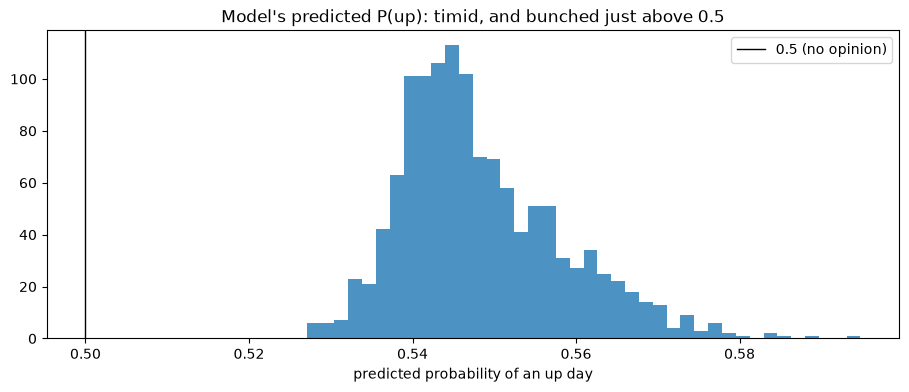

In [6]:
# The raw weights the model learned. We deliberately do NOT rank features by these:
# a weight's size depends on its feature's scale (RSI runs 0-100, returns run ~0.01),
# so the numbers are not comparable. The honest tell is the PROBABILITIES below.
print("learned weight per feature:")
for name, w in zip(feature_cols, logreg.coef_[0]):
    print(f"  {name:8s} {w:+.3f}")

proba_up = logreg.predict_proba(X_test)[:, 1]
print(f"\npredicted P(up) only ranges {proba_up.min():.2f} to {proba_up.max():.2f}:")
print("every guess sits above 0.5, and barely. The model always whispers 'up'.")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(proba_up, bins=40, alpha=0.8)
ax.axvline(0.5, color="k", lw=1, label="0.5 (no opinion)")
ax.set_title("Model's predicted P(up): timid, and bunched just above 0.5")
ax.set_xlabel("predicted probability of an up day")
ax.legend()
plt.show()

**Read the histogram.** Every prediction is crammed into a thin strip *just above*
0.5. The model never says "I am confident this is an up day" (nothing out near 0.80)
and never commits to down (nothing below 0.5); it just leans **barely** up on almost
every single day. That bunching is the visual signature of a model with no edge:
maximally timid, always whispering the majority guess. A model that had found a real
pattern would show probabilities fanning out toward 0 and 1 on the days it felt
strongly. This one simply never does.

## "But what if we use a fancier model?"

The natural next move is to reach for something more powerful. Let's try a
**decision tree** with no limits and see what happens. Watch the gap between how
it does on the data it *studied* versus data it has *never seen*.

In [7]:
tree = DecisionTreeClassifier(random_state=0)   # unconstrained: free to memorize
tree.fit(X_train, y_train)

tree_train = accuracy_score(y_train, tree.predict(X_train))
tree_test = accuracy_score(y_test, tree.predict(X_test))
print(f"deep tree  train accuracy: {tree_train:.2%}   (memorized the past)")
print(f"deep tree  test  accuracy: {tree_test:.2%}   (learned nothing general)")

deep tree  train accuracy: 100.00%   (memorized the past)
deep tree  test  accuracy: 48.03%   (learned nothing general)


It scored ~100% on the training data and worse than a coin flip on new data. It
did not find a pattern; it **memorized noise**. More flexibility did not help, it
hurt. Here are all three side by side.

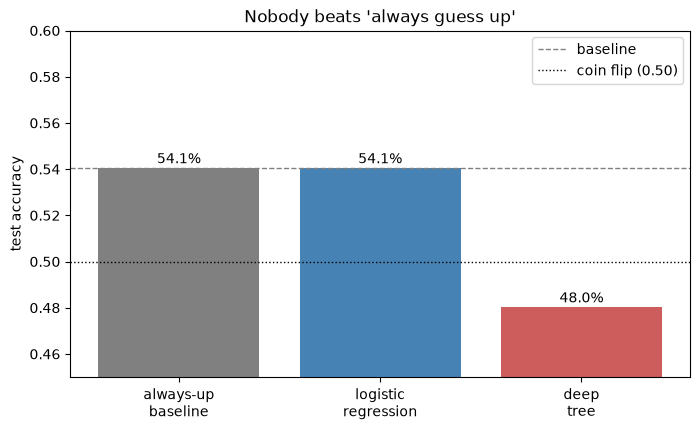

In [8]:
names = ["always-up\nbaseline", "logistic\nregression", "deep\ntree"]
scores = [baseline_acc, acc, tree_test]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, scores, color=["gray", "steelblue", "indianred"])
ax.axhline(baseline_acc, ls="--", color="gray", lw=1, label="baseline")
ax.axhline(0.50, ls=":", color="k", lw=1, label="coin flip (0.50)")
ax.set_ylim(0.45, 0.60)
ax.set_ylabel("test accuracy")
ax.set_title("Nobody beats 'always guess up'")
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.002, f"{s:.1%}", ha="center")
ax.legend()
plt.show()

## Why a coin flip? (the real reason)

Here is the whole problem in one comparison. Each day SPY drifts **up by about
+0.04% on average**, but a *single* day routinely swings about **1.2% up or down**.
So the random daily wiggle is roughly **30 times bigger** than the steady upward
drift. The thing we are trying to call, tomorrow's up-or-down, is a faint signal
drowning in noise many times its size, and today's price-based features simply
cannot hear it over that noise.

There is also a deeper reason markets behave this way: they are roughly
**efficient**. If any simple, public pattern reliably called tomorrow's direction,
traders would pile in and trade it away. What is left over is the slow upward drift
plus randomness, which is exactly what our model found.

**Analogy: the tide and the waves.** The tide (drift) is real but slow; the
individual waves (daily moves) are chaos. You can know the tide is coming in and
still not call the next wave. Our model learned the tide ("always up"), and
honestly, that is all there was to learn.

This result is **expected, not a bug.** It is exactly why the rest of the course
stops trying to predict direction and instead *filters a signal we already trust*.

## A cliffhanger: a tempting shortcut

What if we had split the data the lazy way, **shuffling the days at random** instead
of respecting time? It is one keyword change, `shuffle=True`.

**Why would that change anything?** Our honest split trained on the older years and
tested on the newer ones: two genuinely different stretches of market. Shuffling
instead deals all the days out like a deck of cards into two random piles. Now the
test set is sprinkled all through history, and here is the catch: the day right
*before* a given test day (which looks almost identical to it, similar returns,
similar RSI) is now probably sitting in the **training** pile. The model effectively
gets to study the near-twins of the very days it will be graded on.

For a problem with a real, slow-moving pattern, that is a serious leak (Section 2
shows it manufacturing a large fake edge). Here, on a no-signal problem, watch
whether it changes much at all, and ask whether anything *real* improved.

In [9]:
# train_test_split with shuffle=True scatters the days at RANDOM into train and
# test, ignoring time entirely. Now tomorrow can sit in the training set while
# yesterday is in the test set, so the model effectively gets to study days right
# next to the ones it is graded on. random_state=0 just makes the shuffle repeatable.
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=0)
acc_shuffled = accuracy_score(ys_te, LogisticRegression(max_iter=1000).fit(Xs_tr, ys_tr).predict(Xs_te))

print(f"chronological (honest) accuracy: {acc:.2%}")   # the time-respecting split from earlier
print(f"shuffled-split accuracy:         {acc_shuffled:.2%}")
print("\nShuffling moved the score, but it moved for FREE: we added no skill, we just")
print("reshuffled which days landed in the test set. The number now reflects the luck")
print("of the split, not the model. On this no-signal problem the change is small and")
print("could go either way. The real danger is what this same trick does to a problem")
print("that DOES contain a pattern, which is exactly where Section 2 begins.")

chronological (honest) accuracy: 54.06%
shuffled-split accuracy:         53.98%

Shuffling moved the score, but it moved for FREE: we added no skill, we just
reshuffled which days landed in the test set. The number now reflects the luck
of the split, not the model. On this no-signal problem the change is small and
could go either way. The real danger is what this same trick does to a problem
that DOES contain a pattern, which is exactly where Section 2 begins.


## Recap, and what's next

Five traps to carry forward, each one we just saw on screen:

1. **Accuracy vs baseline**: 54% means nothing next to a 54% baseline.
2. **The accuracy paradox**: when accuracy equals the up-rate, you have likely
   just predicted the majority class.
3. **Overfitting on noise**: the deep tree memorized the past and failed the future.
4. **Leakage via the split**: shuffling time changes the score for free; the
   number then reflects the split, not skill.
5. **One split is one die roll**: never trust a single number.

We ended on a loaded question: shuffling the data moved our score without adding
any skill. Here it barely budged, because there was no signal to inflate. But the
*mechanism* is dangerous. **Section 2** builds a problem that actually contains a
pattern, then shows how this very shuffle can manufacture a large fake edge, and
how honest validation, real trading costs, and proper baselines drag the truth
back into the open.